# **Fake News Detection Using Emotion Amplification and Knowledge Graphs on ISOT Dataset**

**1. Install Required Packages**

In [21]:
!pip install textblob nltk networkx matplotlib scikit-learn pandas seaborn tqdm

**2. Import Libraries**

In [22]:
import pandas as pd
import numpy as np
import re
import nltk
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from scipy.sparse import hstack

# Other NLP tools
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

**3. Load Dataset from Drive**

In [23]:
from google.colab import drive
drive.mount('/content/drive')

true_path = "/content/drive/My Drive/ISOT Dataset/True.csv"
fake_path = "/content/drive/My Drive/ISOT Dataset/Fake.csv"

df_true = pd.read_csv(true_path)
df_fake = pd.read_csv(fake_path)

# Label
df_true['label'] = 1
df_fake['label'] = 0

# Combine and shuffle
df = pd.concat([df_true, df_fake]).sample(frac=1).reset_index(drop=True)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**4. Clean and Prepare Text**

In [24]:
# Combine ONLY TEXT (avoid title leak)
df['text'] = df['text'].fillna('')

# Clean function
def clean_text(text):
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    return text.lower()

df['cleaned'] = df['text'].apply(clean_text)


**5. NRC Emotion Lexicon (Basic Version)**

In [25]:
  >>> import nltk
  >>> nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [26]:
nrc = {
    'fear': ['fear', 'scared', 'afraid', 'terrified'],
    'joy': ['joy', 'happy', 'delight'],
    'anger': ['anger', 'mad', 'furious'],
    'trust': ['trust', 'faith', 'reliable'],
    'disgust': ['disgust', 'repel', 'nausea'],
    'surprise': ['surprise', 'shock', 'amaze'],
    'sadness': ['sadness', 'sorrow', 'cry'],
    'anticipation': ['anticipate', 'expect', 'await']
}

def amplify_sentiment(text):
    tokens = word_tokenize(text)
    emo_score = {k: 0 for k in nrc}
    for token in tokens:
        for emotion, keywords in nrc.items():
            if token in keywords:
                emo_score[emotion] += 1
    return list(emo_score.values())

tqdm.pandas()
emotion_features = df['cleaned'].progress_apply(amplify_sentiment)
emotion_df = pd.DataFrame(emotion_features.tolist(), columns=list(nrc.keys()))


  0%|          | 0/44898 [00:00<?, ?it/s]

**6. TF-IDF Vectorization**

In [27]:
# Reduce feature space to avoid overfitting
tfidf = TfidfVectorizer(
    max_features=1000,   # Limit features
    ngram_range=(1, 2),  # Use unigrams + bigrams
    stop_words='english'
)
X_tfidf = tfidf.fit_transform(df['cleaned'])

# Combine features
X_final = hstack([X_tfidf, emotion_df])
y = df['label']


**7. Split Dataset**

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42, stratify=y)


In [29]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)


MultinomialNB()

**9. Evaluate Model**

In [30]:
from sklearn.metrics import classification_report, accuracy_score

y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9378619153674833

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.94      0.94      4696
           1       0.94      0.93      0.93      4284

    accuracy                           0.94      8980
   macro avg       0.94      0.94      0.94      8980
weighted avg       0.94      0.94      0.94      8980



**Knowledge Graph based on word co-occurrence in cleaned news articles.**

**Build KG from Top Articles:**

In [31]:
def build_kg(texts, max_articles=100):
    G = nx.Graph()
    stop_words = set(stopwords.words('english'))

    for text in texts[:max_articles]:
        sentences = nltk.sent_tokenize(text)
        for sentence in sentences:
            words = word_tokenize(sentence)
            # Lowercase, remove stopwords and non-alpha tokens
            words = [w.lower() for w in words if w.isalpha() and w.lower() not in stop_words]
            for i in range(len(words) - 1):
                G.add_edge(words[i], words[i+1])
    return G


**Build KG on the Data**

In [32]:
import networkx as nx
import matplotlib.pyplot as plt

In [33]:
# Use the 'cleaned' column (or original 'text' if you prefer)
G = build_kg(df['cleaned'].tolist(), max_articles=200)


**Visualize a Subgraph**

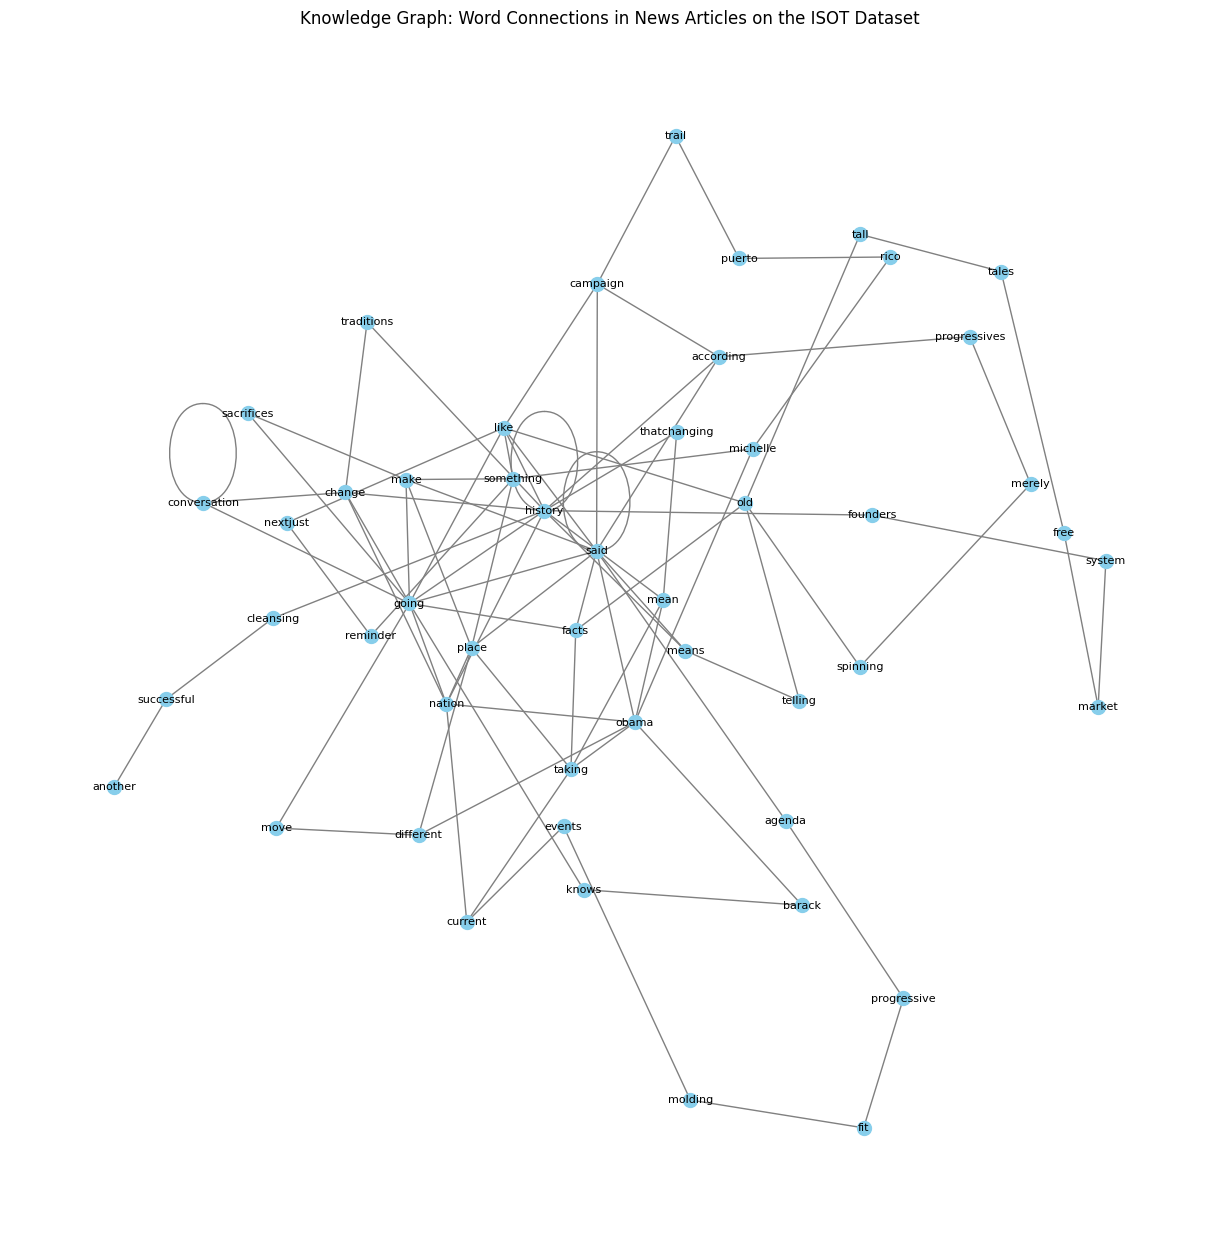

In [34]:
plt.figure(figsize=(12, 12))

# Use first 50 nodes for visualization
subgraph = G.subgraph(list(G.nodes)[:50])

# Spring layout for spacing
pos = nx.spring_layout(subgraph, k=0.5)

# Draw
nx.draw(
    subgraph, pos,
    with_labels=True,
    node_size=100,
    font_size=8,
    node_color='skyblue',
    edge_color='gray'
)

plt.title("Knowledge Graph: Word Connections in News Articles on the ISOT Dataset")
plt.show()
